In [6]:
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np

from skimage import exposure, filters, morphology, measure, color, img_as_float, feature, transform

(540, 800) float64


/tmp/ipykernel_27791/521519428.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/165_HC.png")


(-0.5, 799.5, 539.5, -0.5)

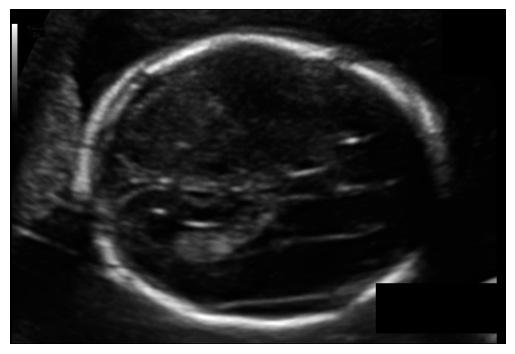

In [22]:
im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/165_HC.png")
im = (im - im.min()) / (im.max() - im.min())

print(im.shape, im.dtype)
plt.imshow(im, cmap="gray")
plt.axis("off")

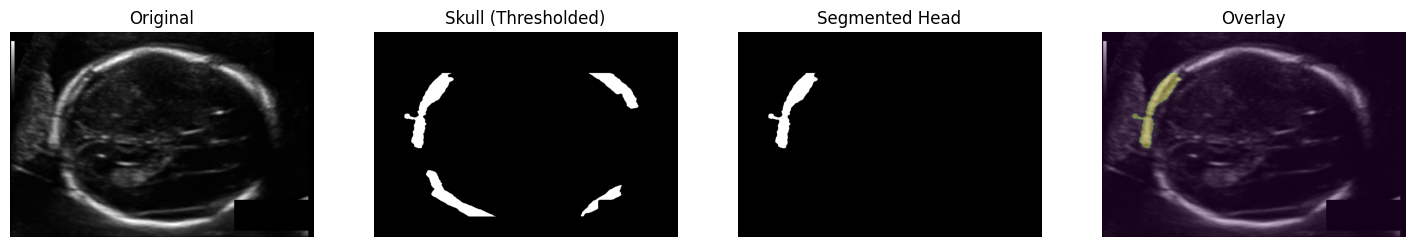

In [23]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import filters, morphology, feature
from skimage.measure import label, regionprops

# --- 1. Preprocessing ---
im_filt = ndi.median_filter(im, size=3)

h, w = im.shape

# --- 2. ROI (remove top artifact region) ---
mask_roi = np.zeros_like(im_filt, dtype=bool)
mask_roi[int(h*0.2):int(h*0.9), int(w*0.1):int(w*0.9)] = True

# --- 3. Skull segmentation (thresholding) ---
th = filters.threshold_otsu(im_filt)
skull = im_filt > th

# Apply ROI early
skull = skull & mask_roi

# Remove small noise
skull = morphology.remove_small_objects(skull, min_size=1000)

# Optional: smooth edges a bit
skull = morphology.binary_closing(skull, morphology.disk(3))

# --- 4. Keep only largest connected component ---
labels = label(skull)
regions = regionprops(labels)

if len(regions) == 0:
    raise ValueError("No regions detected. Check thresholding.")

best_score = -1
best_region = None

for r in regions:
    cy, cx = r.centroid
    
    # 1. Prefer regions lower in image (penalize top)
    position_score = cy / h   # higher = lower in image
    
    # 2. Circularity (important)
    circularity = 4 * np.pi * r.area / (r.perimeter**2 + 1e-6)
    
    # 3. Combine score (tune weights if needed)
    score = (0.6 * position_score) + (0.4 * circularity)
    
    if score > best_score:
        best_score = score
        best_region = r

head_mask = labels == best_region.label
head_mask = labels == largest.label

# --- 5. Fill inside (convert skull ring → full head) ---
head_filled = ndi.binary_fill_holes(head_mask)
head_filled = morphology.binary_closing(head_filled, morphology.disk(5))

# --- 6. Final cleanup ---
head_filled = morphology.binary_closing(head_filled, morphology.disk(5))

# --- 7. Visualization ---
fig, ax = plt.subplots(1, 4, figsize=(18, 5))

ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(skull, cmap='gray')
ax[1].set_title('Skull (Thresholded)')
ax[1].axis('off')

ax[2].imshow(head_filled, cmap='gray')
ax[2].set_title('Segmented Head')
ax[2].axis('off')

# Overlay for verification
ax[3].imshow(im, cmap='gray')
ax[3].imshow(head_filled, alpha=0.3)
ax[3].set_title('Overlay')
ax[3].axis('off')

plt.show()